In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# train_df = pd.read_csv("url_features_extracted1_updated.csv")
train_df = pd.read_csv("url_features_extracted1.csv")
test_df = pd.read_csv("dataset_kampus_legitphish_style.csv")

X_train = train_df.drop(columns=["ClassLabel", "URL"])
y_train = train_df["ClassLabel"]

X_test = test_df.drop(columns=["ClassLabel", "URL"])
y_test = test_df["ClassLabel"]

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Columns:", train_df.columns.tolist()[:30])
print("Columns:", test_df.columns.tolist()[:30])

Train shape: (101219, 18)
Test shape : (1182, 18)
Columns: ['URL', 'url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars', 'ClassLabel']
Columns: ['URL', 'url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars', 'ClassLabel']


In [4]:
svm_pipeline = Pipeline([
    ("clf", LinearSVC(
        penalty="l2",
        loss="squared_hinge",
        dual=False,
        max_iter=5000,
        random_state=42
    ))
])

lr_pipeline = Pipeline([
    ("clf", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=3000,
        random_state=42
    ))
])

models_classic = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "SVM": svm_pipeline,
    "LogisticRegression": lr_pipeline
}

In [1]:
def recursive_feature_elimination(model, X_train, y_train, X_test, y_test, min_features=1):
    features = list(X_train.columns)
    results = []

    while len(features) >= min_features:

        X_train_sel = X_train[features]
        X_test_sel = X_test[features]

        estimator = model.named_steps["clf"] if hasattr(model, "named_steps") else model

        scaler = StandardScaler()
        X_train_sel = scaler.fit_transform(X_train_sel)
        X_test_sel = scaler.transform(X_test_sel)
    
        model.fit(X_train_sel, y_train)

        #akurasi
        acc_train = accuracy_score(y_train, model.predict(X_train_sel))
        acc_test = accuracy_score(y_test, model.predict(X_test_sel))
        #precision
        prec_train = precision_score(y_train, model.predict(X_train_sel))
        prec_test = precision_score(y_test, model.predict(X_test_sel))
        #recall
        rec_train = recall_score(y_train, model.predict(X_train_sel))
        rec_test = recall_score(y_test, model.predict(X_test_sel))
        #f1-score
        f1_train = f1_score(y_train, model.predict(X_train_sel))
        f1_test = f1_score(y_test, model.predict(X_test_sel))

        results.append({
            "jumlah_fitur": len(features),
            "fitur": features.copy(),
            "acc_train": acc_train,
            "acc_test": acc_test,
            "prec_train": prec_train,
            "prec_test": prec_test,
            "rec_train": rec_train,
            "rec_test": rec_test,
            "f1_train": f1_train,
            "f1_test": f1_test
        })

        if hasattr(estimator, "feature_importances_"):
            importance = estimator.feature_importances_
        elif hasattr(estimator, "coef_"):
            importance = np.mean(np.abs(estimator.coef_), axis=0)
        else:
            raise ValueError("Model tidak mendukung RFE")

        idx_min = np.argmin(importance)
        features.pop(idx_min)

    return results

In [5]:
label_col = "ClassLabel"
drop_cols = ["URL"] if "URL" in train_df.columns else []

feature_cols = [
    col for col in train_df.columns
    if col not in drop_cols + [label_col]
]

print("Jumlah fitur:", len(feature_cols))
print(feature_cols)

Jumlah fitur: 16
['url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars']


In [6]:
X_train = train_df[feature_cols]
y_train = train_df[label_col]

X_test = test_df[feature_cols]
y_test = test_df[label_col]

In [58]:
import seaborn as sns

def plot_cm(y_true, y_pred, title):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(5,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=["Legitimate", "Phishing"],
              yticklabels=["Legitimate", "Phishing"])
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(title)
  plt.show()

=== RandomForest ===
Akurasi: 0.817258883248731
Precision: 0.7323420074349443
Recall: 1.0
F1 Score: 0.8454935622317596


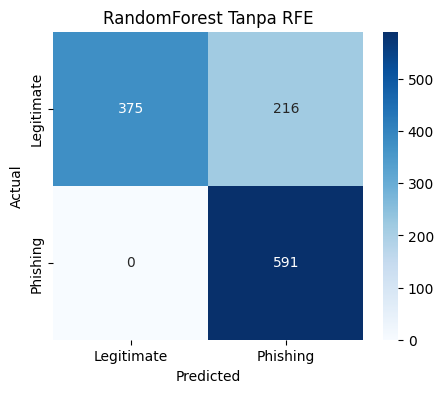


=== SVM ===
Akurasi: 0.7233502538071066
Precision: 0.7082018927444795
Recall: 0.7597292724196277
F1 Score: 0.7330612244897959


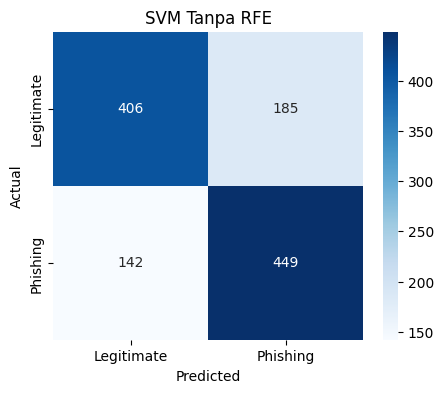


=== LogisticRegression ===
Akurasi: 0.7360406091370558
Precision: 0.8
Recall: 0.6294416243654822
F1 Score: 0.7045454545454546


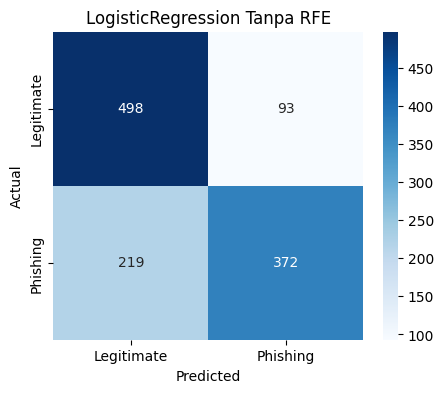

In [11]:
for name, model in models_classic.items():
  print("=== {} ===".format(name))

  pipe = Pipeline([
      ("scaler", StandardScaler()),
      ("model", model)
  ])

  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  print("Akurasi:", accuracy_score(y_test, y_pred))
  print("Precision:", precision_score(y_test, y_pred))
  print("Recall:", recall_score(y_test, y_pred))
  print("F1 Score:", f1_score(y_test, y_pred))
  plot_cm(y_test, y_pred, f"{name} Tanpa RFE")
  print()

In [28]:
for name, model in models_classic.items():
  print("=== ", name, " ===")
  hasil = recursive_feature_elimination(model, X_train, y_train, X_test, y_test, min_features=1)

  df_hasil = pd.DataFrame(hasil)
  print(df_hasil[["jumlah_fitur", "acc_test", "prec_test", "rec_test", "f1_test"]])
  print()

===  RandomForest  ===
    jumlah_fitur  acc_test  prec_test  rec_test   f1_test
0             16  0.817259   0.732342       1.0  0.845494
1             15  0.787648   0.701900       1.0  0.824843
2             14  0.772420   0.687209       1.0  0.814611
3             13  0.781726   0.696113       1.0  0.820833
4             12  0.788494   0.702735       1.0  0.825419
5             11  0.743655   0.661074       1.0  0.795960
6             10  0.719966   0.640998       1.0  0.781229
7              9  0.731810   0.650881       1.0  0.788526
8              8  0.714044   0.636168       1.0  0.777632
9              7  0.719120   0.640303       1.0  0.780713
10             6  0.718274   0.639610       1.0  0.780198
11             5  0.684433   0.613071       1.0  0.760129
12             4  0.586294   0.547222       1.0  0.707361
13             3  0.593063   0.551306       1.0  0.710764
14             2  0.998308   0.996627       1.0  0.998311
15             1  1.000000   1.000000       1.0  

Akurasi: 0.7174280879864636
Precision: 0.6389189189189189
Recall: 1.0
F1 Score: 0.7796833773087071


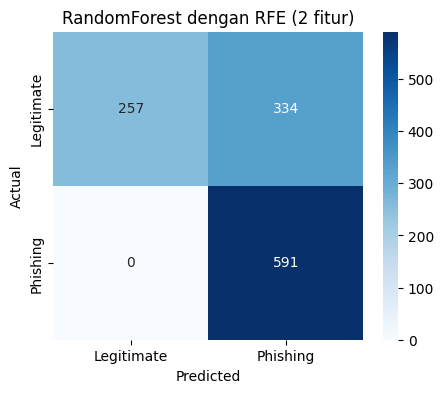

Akurasi: 0.565989847715736
Precision: 0.5353260869565217
Recall: 1.0
F1 Score: 0.6973451327433628


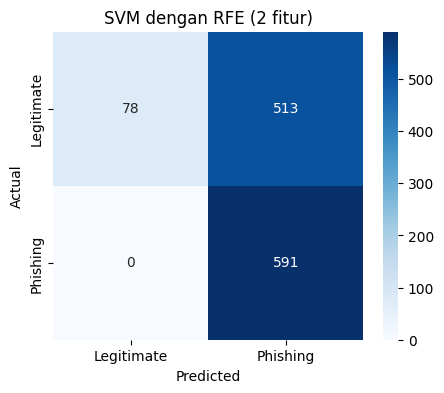

Akurasi: 0.565989847715736
Precision: 0.5353260869565217
Recall: 1.0
F1 Score: 0.6973451327433628


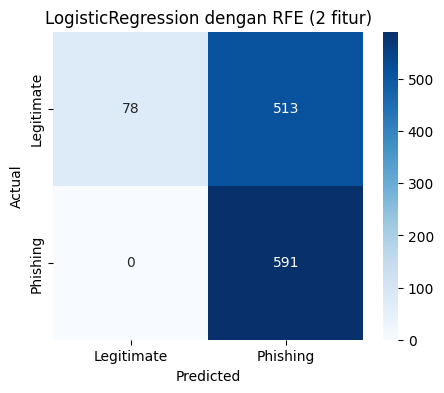

In [ ]:
for name, model in models_classic.items():
    best_row = [r for r in hasil if r["jumlah_fitur"] == 2][0]
    best_features = best_row["fitur"]

    X_train_sel = X_train[best_features]
    X_test_sel = X_test[best_features]

    if name in ["SVM", "LogisticRegression"]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        pipe = Pipeline([
            ("model", model)
        ])

    pipe.fit(X_train_sel, y_train)
    y_pred = pipe.predict(X_test_sel)

    print("Akurasi:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    plot_cm(
        y_test,
        y_pred,
        f"{name} dengan RFE"
    )

In [26]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

for name, model in models_classic.items():
  print("=== ", name, " ===")
  hasil = recursive_feature_elimination(model, X_train, y_train, X_test, y_test, min_features=1)

  for row in hasil:
    print(
        f"{row['jumlah_fitur']} fitur | "
        f"Test={row['acc_test']:.4f}"
    )
  print()

===  RandomForest  ===
16 fitur | Test=0.8173
15 fitur | Test=0.7876
14 fitur | Test=0.7724
13 fitur | Test=0.7817
12 fitur | Test=0.7885
11 fitur | Test=0.7437
10 fitur | Test=0.7200
9 fitur | Test=0.7318
8 fitur | Test=0.7140
7 fitur | Test=0.7191
6 fitur | Test=0.7183
5 fitur | Test=0.6844
4 fitur | Test=0.5863
3 fitur | Test=0.5931
2 fitur | Test=0.9983
1 fitur | Test=1.0000

===  SVM  ===
16 fitur | Test=0.7234
15 fitur | Test=0.7369
14 fitur | Test=0.7327
13 fitur | Test=0.7183
12 fitur | Test=0.7453
11 fitur | Test=0.6151
10 fitur | Test=0.5592
9 fitur | Test=0.5592
8 fitur | Test=0.5431
7 fitur | Test=0.5355
6 fitur | Test=0.5355
5 fitur | Test=0.5355
4 fitur | Test=0.5347
3 fitur | Test=0.4992
2 fitur | Test=0.4992
1 fitur | Test=0.4924

===  LogisticRegression  ===
16 fitur | Test=0.7360
15 fitur | Test=0.7149
14 fitur | Test=0.7064
13 fitur | Test=0.7462
12 fitur | Test=0.7606
11 fitur | Test=0.6920
10 fitur | Test=0.6904
9 fitur | Test=0.6701
8 fitur | Test=0.6489
7 fitur |

In [12]:
def get_best_2_features(model, X_train, y_train, X_test, y_test):
  hasil = recursive_feature_elimination(
      model,
      X_train,
      y_train,
      X_test,
      y_test,
      min_features=2
  )
  return hasil[-1]

In [13]:
for name, model in models_classic.items():
  print("=== ", name, " ===")
  best_2_features = get_best_2_features(model, X_train, y_train, X_test, y_test)
  print("Fitur:", best_2_features["fitur"])

===  RandomForest  ===
Fitur: ['token_count', 'path_length']
===  SVM  ===
Fitur: ['dot_count', 'subdomain_count']
===  LogisticRegression  ===
Fitur: ['dot_count', 'https_flag']


---

---

In [14]:
def feature_ranking(model, X_train, y_train):

    # ambil estimator jika model berupa pipeline
    estimator = model.named_steps["clf"] if hasattr(model, "named_steps") else model

    # scaling (penting untuk model linear)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # training model
    model.fit(X_scaled, y_train)

    # ambil skor fitur
    if hasattr(estimator, "feature_importances_"):
        scores = estimator.feature_importances_

    elif hasattr(estimator, "coef_"):
        scores = np.mean(np.abs(estimator.coef_), axis=0)

    else:
        raise ValueError("Model tidak memiliki skor fitur")

    # buat dataframe ranking
    ranking = pd.DataFrame({
        "Feature": X_train.columns,
        "Score": scores
    })

    ranking = ranking.sort_values(by="Score", ascending=False).reset_index(drop=True)

    return ranking

In [15]:
for name, model in models_classic.items():
    print("=== ", name, "===")

    ranking = feature_ranking(model, X_train, y_train)

    print(ranking)
    print()

===  RandomForest ===
                      Feature     Score
0                 path_length  0.343453
1                 token_count  0.169947
2    percentage_numeric_chars  0.139188
3            number_of_digits  0.108577
4                  https_flag  0.105069
5                   dot_count  0.044227
6             subdomain_count  0.028846
7          domain_name_length  0.016006
8              has_ip_address  0.015588
9                  url_length  0.012879
10                 tld_length  0.007594
11                url_entropy  0.003224
12  suspicious_file_extension  0.001754
13          query_param_count  0.001747
14             tld_popularity  0.001661
15       has_hyphen_in_domain  0.000240

===  SVM ===
                      Feature     Score
0             subdomain_count  1.026923
1                   dot_count  0.936508
2                  https_flag  0.859189
3                 token_count  0.772636
4                 path_length  0.644656
5              has_ip_address  0.542257
6   

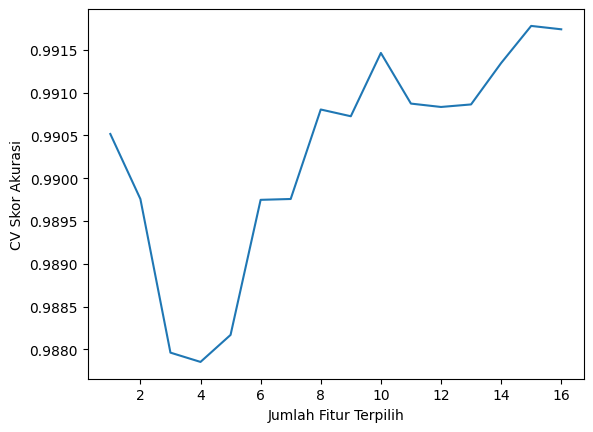

Jumlah fitur terpilih: 15
Ranking fitur terbaik: [1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1]
Fitur terbaik: [ True  True  True  True  True  True  True  True  True  True False  True
  True  True  True  True]
Skor terbaik: 0.9917800686277314
Fitur terpilih: ['url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars']


In [16]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Contoh: gunakan RandomForestClassifier, bisa diganti model lain
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# RFECV setup
rfecv = RFECV(
    estimator=model,
    step=1,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    # importance_getter="named_steps.clf.coef_"
)

# Fit RFECV ke data training
rfecv.fit(X_train, y_train)

X_train_selected = rfecv.transform(X_train)
X_test_selected = rfecv.transform(X_test)

# Visualisasi hasil RFECV
plt.figure()
plt.xlabel("Jumlah Fitur Terpilih")
plt.ylabel("CV Skor Akurasi")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.show()

print("Jumlah fitur terpilih:", rfecv.n_features_)
print("Ranking fitur terbaik:", rfecv.ranking_)
print("Fitur terbaik:", rfecv.support_)
print("Skor terbaik:", rfecv.cv_results_['mean_test_score'][rfecv.n_features_ - 1])
print("Fitur terpilih:", X_train.columns[rfecv.support_].tolist())

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rfecv = RFECV(
    estimator=rf,
    step=1,
    cv=StratifiedKFold(10),
    scoring="accuracy",
    # importance_getter="named_steps.clf.coef_"
)

rfecv.fit(X_train, y_train)

selected_features = X_train.columns[rfecv.support_]

print("Jumlah fitur optimal:", rfecv.n_features_)
print("Fitur terpilih:", list(selected_features))

In [18]:
scores = rfecv.cv_results_['mean_test_score']
n_features = list(range(1, len(scores) + 1))

for n, s in zip(n_features, scores):
    print(f"{n} fitur -> {s:.4f}")

1 fitur -> 0.9905
2 fitur -> 0.9897
3 fitur -> 0.9891
4 fitur -> 0.9878
5 fitur -> 0.9878
6 fitur -> 0.9900
7 fitur -> 0.9896
8 fitur -> 0.9908
9 fitur -> 0.9907
10 fitur -> 0.9917
11 fitur -> 0.9908
12 fitur -> 0.9909
13 fitur -> 0.9918
14 fitur -> 0.9917
15 fitur -> 0.9919
16 fitur -> 0.9918


In [55]:
def plot_rfe_stability(results, model_name):

  jumlah_fitur = [r["jumlah_fitur"] for r in results]
  acc_train = [r["acc_train"] for r in results]
  acc_test = [r["acc_test"] for r in results]

  plt.figure(figsize=(8,5))

  # plt.plot(jumlah_fitur, acc_train, marker='o', label="Train Accuracy")
  plt.plot(jumlah_fitur, acc_test, marker='o', label="Test Accuracy")

  plt.xlabel("Jumlah Fitur")
  plt.ylabel("Accuracy")
  plt.title(f"Stabilitas Akurasi RFE - {model_name}")

  plt.gca().invert_xaxis()  # dari banyak → sedikit fitur
  plt.legend()
  plt.grid(True)

  plt.show()

=== RandomForest ===


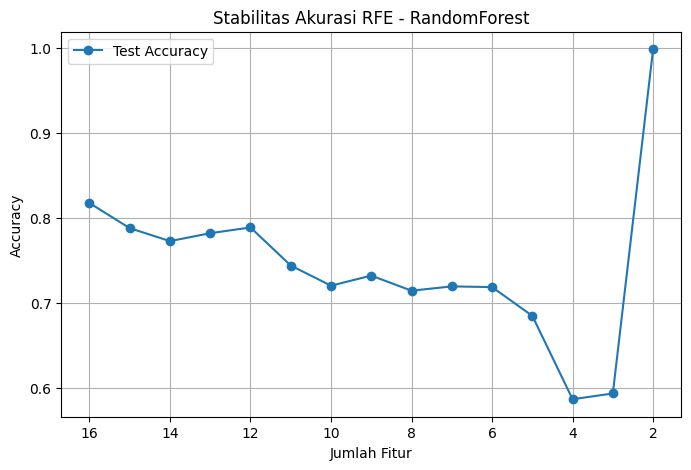

=== SVM ===


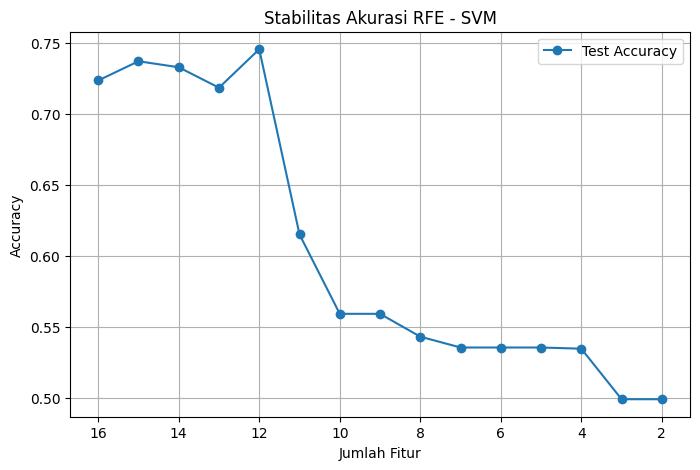

=== LogisticRegression ===


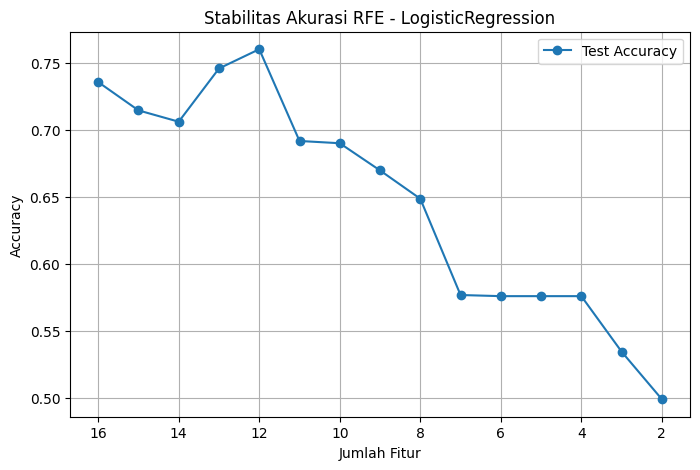

In [56]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

all_results = {}

for name, model in models_classic.items():

    print("===", name, "===")

    hasil = recursive_feature_elimination(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        min_features=2
    )

    all_results[name] = hasil
    plot_rfe_stability(hasil, name)

In [12]:
def find_convergence_feature(results, tolerance=0.001):
    best_acc = max(r["acc_test"] for r in results)
    threshold = best_acc - tolerance

    candidates = [
        r for r in results
        if r["acc_test"] >= threshold
    ]

    # pilih fitur paling sedikit
    optimal = min(candidates, key=lambda x: x["jumlah_fitur"])

    return optimal

Jumlah fitur optimal: 12
Fitur: ['url_length', 'has_ip_address', 'dot_count', 'https_flag', 'token_count', 'subdomain_count', 'query_param_count', 'path_length', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars']
Accuracy: 0.760575296108291


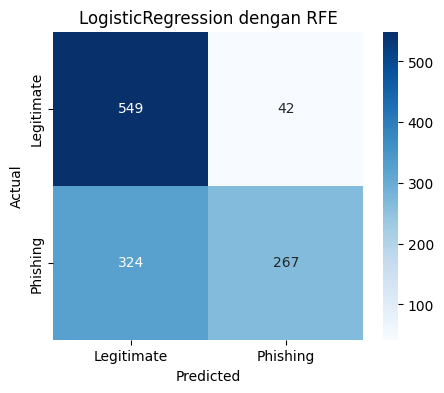

In [59]:
rf_optimal = find_convergence_feature(
    all_results["LogisticRegression"]
)

print("Jumlah fitur optimal:", rf_optimal["jumlah_fitur"])
print("Fitur:", rf_optimal["fitur"])
print("Accuracy:", rf_optimal["acc_test"])
plot_cm(
    y_test,
    y_pred,
    f"{name} dengan RFE"
)

In [ ]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(
        penalty="l2",
        loss="squared_hinge",
        dual=False,
        max_iter=5000,
        random_state=42
    ))
])

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=3000,
        random_state=42
    ))
])

models_tuning = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "SVM": svm_pipeline,
    "LogisticRegression": lr_pipeline
}

param_grid = {
    "RandomForest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]},
    "SVM": {
        "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "clf__loss": ["squared_hinge"],
        "clf__penalty": ["l2"]},
    "LogisticRegression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__penalty": ["l2"]}}

best_models = {}
results = []

for name, model in models_tuning.items():

    # print(f"Tuning {name}...")

    # 1. jalankan RFE
    rfe_results = recursive_feature_elimination(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        min_features=2
    )

    # 2. cari titik konvergensi
    optimal_feature = find_convergence_feature(rfe_results, tolerance=0.001)

    best_features = optimal_feature["fitur"]

    # print("Fitur konvergen:", best_features)
    # print("Jumlah fitur:", optimal_feature["jumlah_fitur"])
    # print("Accuracy test:", optimal_feature["acc_test"])

    # 3. bentuk dataset baru
    X_train_best = X_train[best_features]
    X_test_best = X_test[best_features]

    # 4. tuning model dengan fitur hasil RFE
    grid = GridSearchCV(model, param_grid[name], cv=5, scoring="accuracy", n_jobs=-1)

    grid.fit(X_train_best, y_train)

    best_models[name] = {"model": grid.best_estimator_, "features": best_features}

    results.append({"Model": name, "Best Params": grid.best_params_, "Best CV Score": float(grid.best_score_),})

for r in results:
    print(r)

{'Model': 'RandomForest', 'Best Params': {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}, 'Best CV Score': 0.9933214701600802}
{'Model': 'SVM', 'Best Params': {'clf__C': 0.1, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l2'}, 'Best CV Score': 0.9921655218477049}
{'Model': 'LogisticRegression', 'Best Params': {'clf__C': 10, 'clf__penalty': 'l2'}, 'Best CV Score': 0.992659509523994}


In [51]:
from sklearn.metrics import accuracy_score, classification_report

print("\n=== Evaluation After RFE + Tuning ===")

for name, data in best_models.items():

    model = data["model"]
    features = data["features"]

    X_test_eval = X_test[features]

    y_pred = model.predict(X_test_eval)

    acc = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()

    print(f"\n{name}")
    # print("Features used:", features)
    print("Accuracy:", acc)
    print(df_report)


=== Evaluation After RFE + Tuning ===

RandomForest
Accuracy: 0.9991539763113367
              precision    recall  f1-score      support
0              1.000000  0.998308  0.999153   591.000000
1              0.998311  1.000000  0.999155   591.000000
accuracy       0.999154  0.999154  0.999154     0.999154
macro avg      0.999155  0.999154  0.999154  1182.000000
weighted avg   0.999155  0.999154  0.999154  1182.000000

SVM
Accuracy: 0.6446700507614214
              precision    recall  f1-score     support
0              0.776699  0.406091  0.533333   591.00000
1              0.597938  0.883249  0.713115   591.00000
accuracy       0.644670  0.644670  0.644670     0.64467
macro avg      0.687319  0.644670  0.623224  1182.00000
weighted avg   0.687319  0.644670  0.623224  1182.00000

LogisticRegression
Accuracy: 0.6903553299492385
              precision    recall  f1-score      support
0              0.628866  0.928934  0.750000   591.000000
1              0.864078  0.451777  0.593333

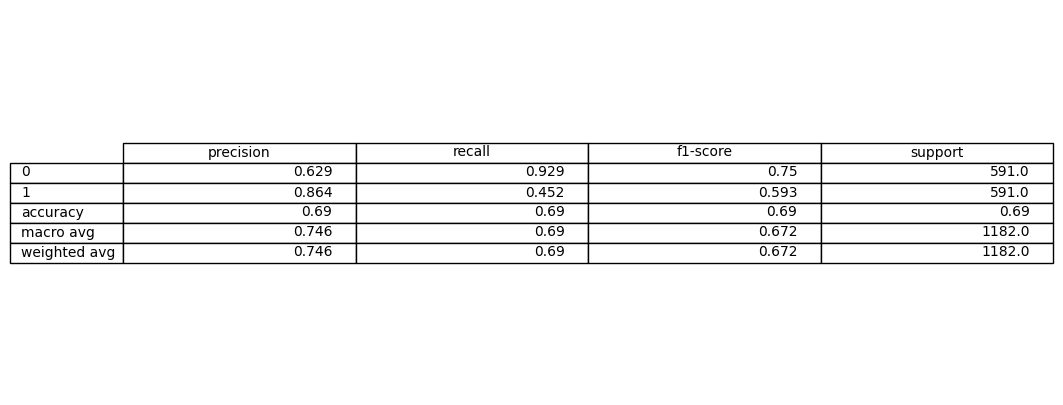

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

table = ax.table(
    cellText=df_report.values,
    colLabels=df_report.columns,
    rowLabels=df_report.index,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()

In [36]:
result_tuning = pd.DataFrame(grid.cv_results_)
table = result_tuning[["param_clf__C", "param_clf__penalty", "mean_test_score"]]
table = table.sort_values(by="mean_test_score", ascending=False)
print(table)

   param_clf__C param_clf__penalty  mean_test_score
3         10.00                 l2         0.992660
2          1.00                 l2         0.992343
1          0.10                 l2         0.992185
0          0.01                 l2         0.991089


In [61]:
import pickle
import warnings
warnings.filterwarnings('ignore')

# Dua fitur terbaik hasil RFE
# model LR
# best_features = ['url_length', 'has_ip_address', 'dot_count', 'https_flag', 'token_count', 'subdomain_count', 'query_param_count', 'path_length', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars']
# best_features = ['has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count',
#                  'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'tld_popularity',
#                  'suspicious_file_extension']
# model SVM
# best_features = ['url_length', 'has_ip_address', 'dot_count',
# 'https_flag', 'token_count', 'subdomain_count', 'query_param_count', 'path_length', 'tld_popularity', 
# 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars']
# model RF
# best_features = ['token_count', 'path_length']

#model RF updated
# best_features = ['url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 
#                 'subdomain_count', 'tld_length', 'path_length', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 
#                 'domain_name_length', 'percentage_numeric_chars']

# X_train_2 = X_train[best_features]
# X_test_2 = X_test[best_features]

# Latih ulang model
rf_best = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    # ("clf", LogisticRegression(
    #     penalty="l2",
    #     solver="liblinear",
    #     max_iter=3000,
    #     random_state=42
    # ))
    ("clf", LinearSVC(
        penalty="l2",
        loss="squared_hinge",
        dual=False,
        max_iter=5000,
        random_state=42
    ))
])

rf_best.fit(X_train, y_train)

# Evaluasi
acc_test = accuracy_score(y_test, rf_best.predict(X_test))
print("Final Test Accuracy:", acc_test)

Final Test Accuracy: 0.8189509306260575


In [62]:
with open("rf_all.pkl", "wb") as f:
    pickle.dump(rf_best, f)

print("Model berhasil disimpan.")

Model berhasil disimpan.
